# 1. Loading

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from loguru import logger
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import KFold, TimeSeriesSplit, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, l, te
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted

random_seed = 42

In [2]:
TIME_SPLIT = False

In [3]:
WINDOW_LENGTH = "5min"

In [4]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
engineered_data_path = os.path.join(notebook_parent_parent_dir, 'data', 'engineered', f'engineered_features_{WINDOW_LENGTH}.csv')

In [5]:
df = pd.read_csv(engineered_data_path)
df["window_start"] = pd.to_datetime(df["window_start"], format='ISO8601', utc=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47597 entries, 0 to 47596
Data columns (total 57 columns):
 #   Column                                                                 Non-Null Count  Dtype              
---  ------                                                                 --------------  -----              
 0   seg_id                                                                 47597 non-null  int64              
 1   window_start                                                           47597 non-null  datetime64[us, UTC]
 2   Vessel Hull Over Ground Speed (knots)                                  47597 non-null  float64            
 3   Vessel Hull Through Water Longitudinal Speed (knots)                   47597 non-null  float64            
 4   Vessel External Conditions Wind Relative Speed (knots)                 47597 non-null  float64            
 5   Vessel External Conditions Wind Relative Angle (degrees)               47597 non-null  float64            
 6   V

# 3. Predictive models

This section defines a predictor set and benchmarks multiple machine learning models to predict shaft power.

## 3.1. Ridge vs GAM vs Random Forest

### 3.1.1. Setup

#### 3.1.1.1. Defining variables

In [7]:
TARGET_COLUMN = "Vessel Propeller Shaft Mechanical Power (KW)"

predictive_sensor_variables = [
    "Avg Draft (Calculated)",
    "Draft Trim (Calculated)",
    "Vessel Hull Through Water Longitudinal Speed (knots)",
    "Days Since Last Cleaning",
#    "Speed Through Water^3 (m/s)",
#    "Main Engine Fuel Load % (%)",
#   "Vessel Propeller Shaft Thrust Force (KN)",
#    "Vessel Propeller Shaft Rotational Speed (rpm)",
]

predictive_weather_variables = [
    "Vessel External Conditions Wind Relative Angle (degrees)",
    "Vessel External Conditions Wind Relative Speed (knots)",
    "Vessel External Conditions Sea Water Temperature (Provider S)",
#    "Vessel External Conditions Northward Sea Water Velocity (Provider MB)", # Make a current variable instead
#    "Vessel External Conditions Eastward Sea Water Velocity (Provider MB)", # Make a current variable instead 
    "Vessel External Conditions Wave Significant Height (Provider MB)",
#    "Vessel External Conditions Swell Significant Height (Provider MB)", # choose either swell or wave due to collinearity
#    "Vessel External Conditions Eastward Wind Velocity (Provider S)",
#    "Vessel External Conditions Wind True Angle (Provider MB)",
#    "Vessel External Conditions Wind True Speed (Provider MB)",
]

all_predictive_variables = predictive_sensor_variables + predictive_weather_variables

print(f"Target variable: {TARGET_COLUMN}")
print(f"Number of predictive variables: {len(all_predictive_variables)}")
print("Predictive variables:")
for variable in all_predictive_variables:
    print(f"- {variable}")

Target variable: Vessel Propeller Shaft Mechanical Power (KW)
Number of predictive variables: 8
Predictive variables:
- Avg Draft (Calculated)
- Draft Trim (Calculated)
- Vessel Hull Through Water Longitudinal Speed (knots)
- Days Since Last Cleaning
- Vessel External Conditions Wind Relative Angle (degrees)
- Vessel External Conditions Wind Relative Speed (knots)
- Vessel External Conditions Sea Water Temperature (Provider S)
- Vessel External Conditions Wave Significant Height (Provider MB)


#### 3.1.1.2. Loading data

In [8]:
model_df = (
    df[["window_start", TARGET_COLUMN] + all_predictive_variables]
    .sort_values("window_start")
    .dropna()
    .copy()
)

X = model_df[all_predictive_variables]
y = model_df[TARGET_COLUMN]

print(f"Rows available for modelling: {len(model_df):,}")
print(f"Feature matrix shape: {X.shape}")

Rows available for modelling: 47,597
Feature matrix shape: (47597, 8)


#### 3.1.1.3. specifying models and pipeline components

In [ ]:

# --- GAM formula construction ---
gam_formula = None

for i, var_name in enumerate(all_predictive_variables):
    
    if var_name == "Days Since Last Cleaning":
        term = s(i, constraints='monotonic_inc', n_splines=15)
        
    elif var_name == "Vessel Hull Through Water Longitudinal Speed (knots)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Avg Draft (Calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
        
    elif var_name == "Vessel External Conditions Sea Water Temperature (Provider S)":
        term = s(i, constraints='monotonic_dec', n_splines=10)
    
    elif var_name == "Vessel External Conditions Wave Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
        
    elif var_name == "Vessel External Conditions Swell Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)

    elif var_name == "Vessel External Conditions Wind Relative Angle (degrees)":
        term = s(i, basis='cp', n_splines=10, edge_knots=[0, 360]) # transformed because the model cannot reed degrees as well

    elif var_name == "Vessel External Conditions Wind Relative Speed (knots)":
        term = s(i, constraints='monotonic_inc', n_splines=15) # EDoF was 8.3 when running with 10, so increased to 15

    else:
        term = s(i, n_splines=10)
        
    # Add the term to the global formula
    if gam_formula is None:
        gam_formula = term
    else:
        gam_formula += term


# --- Wrapper Class ---
class SklearnGAM(BaseEstimator, RegressorMixin):
    def __init__(self, formula, auto_tune=True):
        self.formula = formula
        self.auto_tune = auto_tune
        
    def fit(self, X, y):
        self.gam_model_ = LinearGAM(self.formula)
        
        if self.auto_tune:
            # Provide a wider grid for the smoothing penalty (up to 100,000). Lower bound was expanded from -3 to allow for a more "wiggly" curves
            lam_grid = np.logspace(-6, 3, 20)
            self.gam_model_.gridsearch(X, y, lam=lam_grid)
        else:
            self.gam_model_.fit(X, y)
            
        self.is_fitted_ = True 
        return self

    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
        return self.gam_model_.predict(X)


In [10]:
if TIME_SPLIT:        
    split_index = int(len(model_df) * 0.8)

    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)


numeric_preprocessor = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, all_predictive_variables),
    ]
)

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=500, random_state=random_seed, n_jobs=-1, max_features='sqrt', min_samples_split=2),
    "GAM": SklearnGAM(formula=gam_formula)
}

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")

Train rows: 38,077
Test rows:  9,520


### 3.1.2. Running pipeline

In [11]:
if TIME_SPLIT:
    logger.info("Using TimeSeriesSplit for cross-validation.")
    tscv = TimeSeriesSplit(n_splits=5)
if not TIME_SPLIT:
    logger.info("Using KFold for cross-validation.")
    tscv = KFold(n_splits=5, shuffle=True, random_state=random_seed)

scoring = {
    "mape": "neg_mean_absolute_percentage_error",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

results = []
fitted_pipelines = {}

# Make sure you define your scoring metrics for the CV function
scoring = {
    "mape": "neg_mean_absolute_percentage_error",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    # 1. Run Cross-Validation and keep both train and test (validation) fold scores
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True, # Changed to True so you can see CV fold training scores
    )

    # 2. Fit the final model on the ENTIRE training set
    pipeline.fit(X_train, y_train)
    
    # 3. Predict on train and test sets
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # 4. Save the results, incorporating the CV scores!
    results.append(
        {
            "model": model_name,
            
            # RMSE 
            "train_rmse": root_mean_squared_error(y_train, y_pred_train),
            "cv_rmse_mean": -cv_scores["test_rmse"].mean(),
            "cv_rmse_std": cv_scores["test_rmse"].std(),
            "test_rmse": root_mean_squared_error(y_test, y_pred_test),
            
            # MAPE
            "train_mape": mean_absolute_percentage_error(y_train, y_pred_train),
            "cv_mape_mean": -cv_scores["test_mape"].mean(),
            "cv_mape_std": cv_scores["test_mape"].std(),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred_test),
            
            # MAE
            "train_mae": mean_absolute_error(y_train, y_pred_train),
            "cv_mae_mean": -cv_scores["test_mae"].mean(),
            "cv_mae_std": cv_scores["test_mae"].std(),
            "test_mae": mean_absolute_error(y_test, y_pred_test),
        }
    )

    fitted_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("test_rmse", ascending=True)
results_df.reset_index(drop=True, inplace=True)
display(results_df)

2026-02-24 14:28:24.325 | INFO     | __main__:<module>:5 - Using KFold for cross-validation.
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 10% (2 of 20) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 35% (7 of 20) |########                 | Elapsed Time: 0:00:00 ETA:   0:00:00
 30% (6 of 20) |#######    

,model,train_rmse,cv_rmse_mean,cv_rmse_std,test_rmse,train_mape,cv_mape_mean,cv_mape_std,test_mape,train_mae,cv_mae_mean,cv_mae_std,test_mae
0,RandomForest,19.409735,55.167881,3.786830,47.496481,0.002257,0.006355,0.000080,0.006039,9.166648,25.728634,0.298230,24.553865
1,GAM,493.631312,1492.953890,4.502476,496.380299,0.090503,0.386908,0.003249,0.089976,366.148449,1378.779414,5.006339,365.510416
2,Ridge,703.950193,704.179891,4.025003,694.086720,0.149613,0.149665,0.000453,0.146604,568.039050,568.237401,2.082031,558.920050


### 3.1.3. Quick residual diagnostics

Text(0, 0.5, 'Frequency')

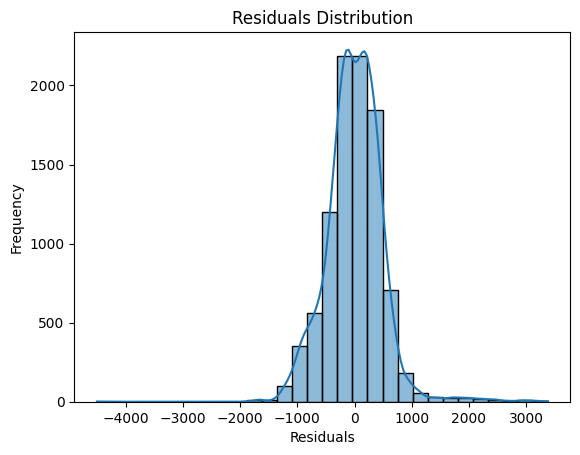

In [12]:
rmse = root_mean_squared_error(y_test, y_pred_test)  # true RMSE [web:156]

histogram = sns.histplot(y_test - y_pred_test, bins=30, kde=True)
histogram.set_title("Residuals Distribution")
histogram.set_xlabel("Residuals")
histogram.set_ylabel("Frequency")

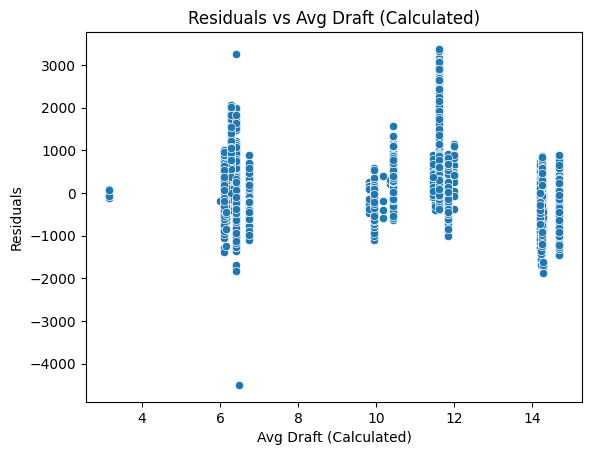

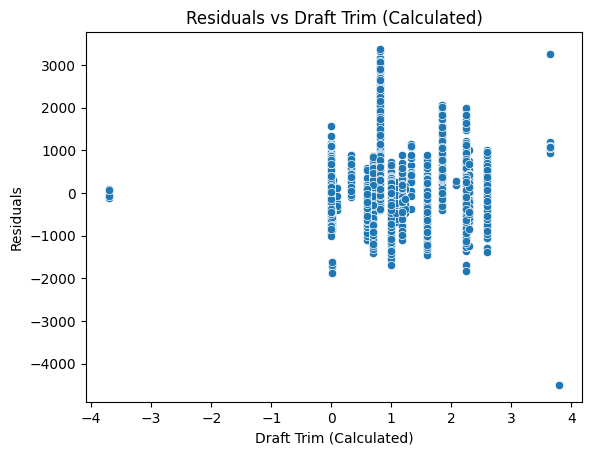

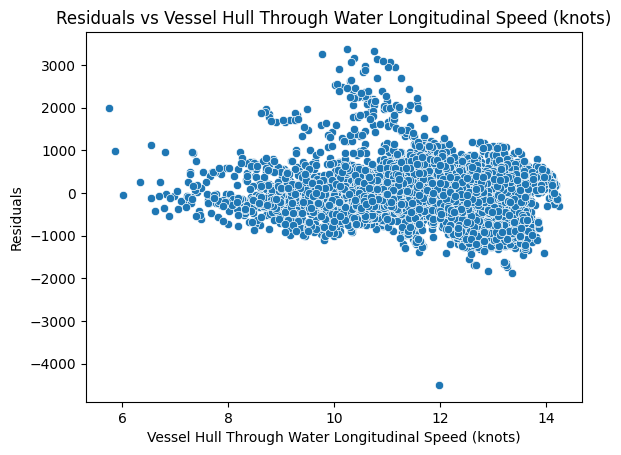

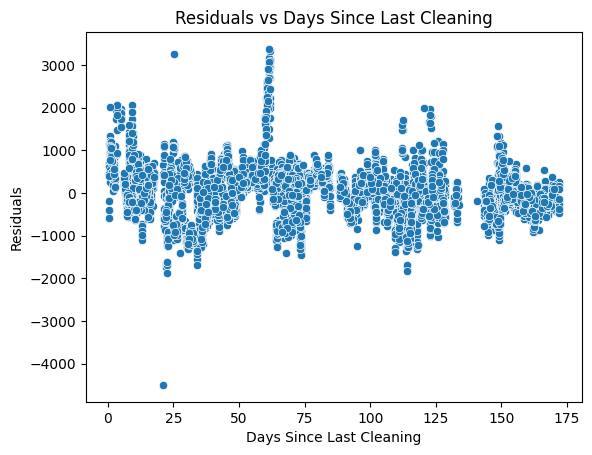

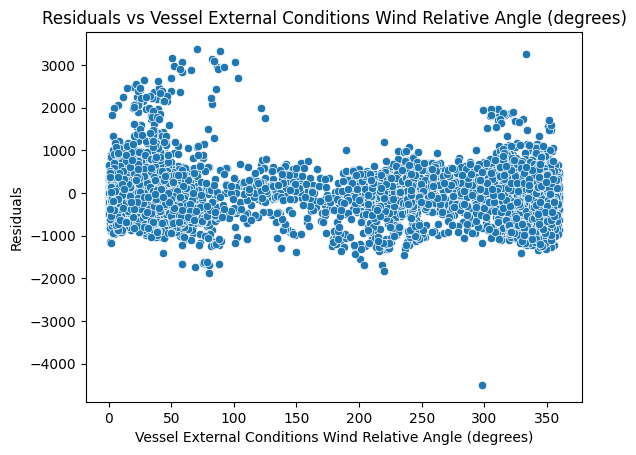

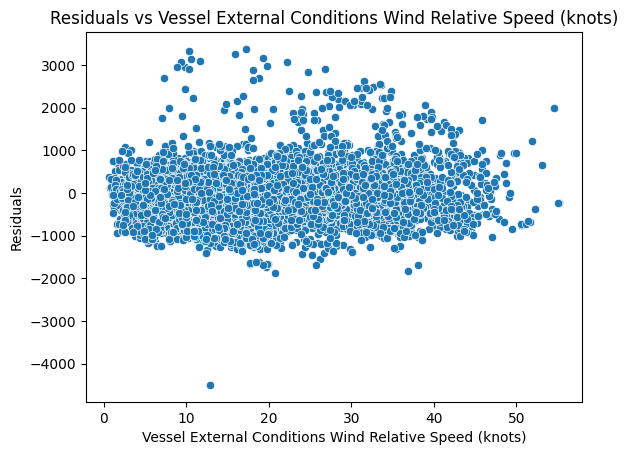

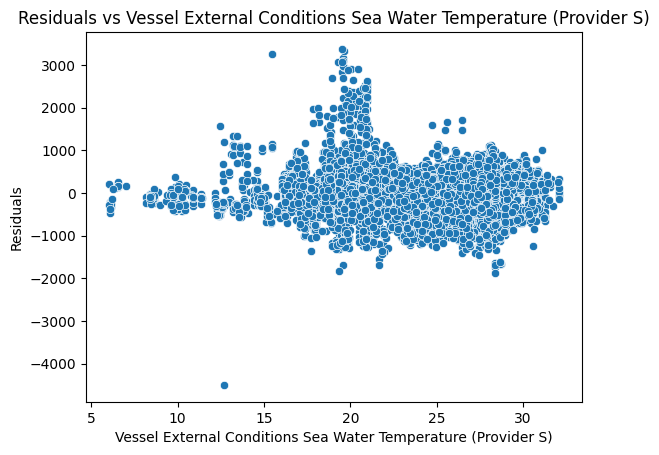

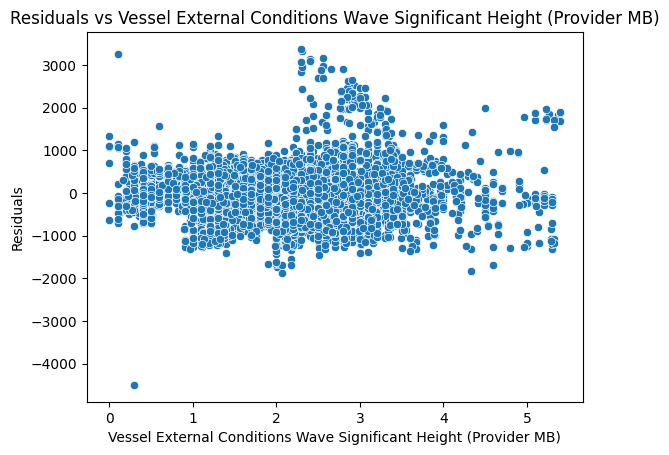

In [13]:
# make scatterplot of the residuals vs the actual values, as well as each of the features (to see what what kind of values it is struggling to predict)
for feature in all_predictive_variables:
    scatter = sns.scatterplot(x=X_test[feature], y=y_test - y_pred_test)
    scatter.set_title(f"Residuals vs {feature}")
    scatter.set_xlabel(feature)
    scatter.set_ylabel("Residuals")
    plt.show()


## 3.2. Synthetic test scenario

### 3.2.1. Setting values

In [14]:
speed_values = [8, 8.5, 9, 9.5,10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14] # for varying speed
dsc_range = range(0, 151, 1) # for varying fouling from 0 to 150 days since cleaning

# split the list of predictive variables into draft and non draft by looking for the word "draft" in the variable name
speed_variable = "Vessel Hull Through Water Longitudinal Speed (knots)"
dsc_variable = "Days Since Last Cleaning"
draft_variables = [feature for feature in all_predictive_variables if "Draft" in feature]
non_draft_variables = [feature for feature in all_predictive_variables if "Draft" not in feature and feature != speed_variable and feature != dsc_variable]
draft_and_non_draft_variables = draft_variables + non_draft_variables

logger.info(f'speed variable: {speed_variable}')
logger.info(f'dsc variable: {dsc_variable}')
logger.info(f"Draft variables: {draft_variables}")
logger.info(f"Non-draft variables: {non_draft_variables}")

# intialize a dictionary and set the keys to be the selected predictive variable names execpt for dsc
typical_values = {feature: [] for feature in all_predictive_variables}

# drop the speed and cleaning date variables from the typical values dict
typical_values.pop(dsc_variable, None)
typical_values.pop(speed_variable, None)

# for the values in the dictionary, take the mean value of each feature in the training set ofr the non-draft variables, and for the draft variables, set them to be the median
for feature in all_predictive_variables:
    if feature in non_draft_variables:
        typical_values[feature] = X_train[feature].mean()
    elif feature in draft_variables:
        # set draft variables to be the median instead
        typical_values[feature] = X_train[feature].median()

typical_values

2026-02-24 14:32:25.872 | INFO     | __main__:<module>:11 - speed variable: Vessel Hull Through Water Longitudinal Speed (knots)
2026-02-24 14:32:25.873 | INFO     | __main__:<module>:12 - dsc variable: Days Since Last Cleaning
2026-02-24 14:32:25.875 | INFO     | __main__:<module>:13 - Draft variables: ['Avg Draft (Calculated)', 'Draft Trim (Calculated)']
2026-02-24 14:32:25.876 | INFO     | __main__:<module>:14 - Non-draft variables: ['Vessel External Conditions Wind Relative Angle (degrees)', 'Vessel External Conditions Wind Relative Speed (knots)', 'Vessel External Conditions Sea Water Temperature (Provider S)', 'Vessel External Conditions Wave Significant Height (Provider MB)']


{'Avg Draft (Calculated)': np.float64(9.945),
 'Draft Trim (Calculated)': np.float64(1.0),
 'Vessel External Conditions Wind Relative Angle (degrees)': np.float64(205.2431728161802),
 'Vessel External Conditions Wind Relative Speed (knots)': np.float64(21.467125335156222),
 'Vessel External Conditions Sea Water Temperature (Provider S)': np.float64(24.299006186380847),
 'Vessel External Conditions Wave Significant Height (Provider MB)': np.float64(2.0123813819983964)}

### 3.2.2. Build synhtetic test set

In [15]:
# build a dataframe with a column for each of the "all predictive variables", and a row for each combination of speed and days since cleaning, where the values in the dataframe are the typical values for each variable, except for speed and days since cleaning which take the values from the lists defined above
simulation_df = pd.DataFrame(columns=all_predictive_variables)
for speed in speed_values:
    for dsc in dsc_range:
        row = {feature: typical_values[feature] for feature in draft_and_non_draft_variables}
        row[speed_variable] = speed
        row[dsc_variable] = dsc
        simulation_df = pd.concat([simulation_df, pd.DataFrame([row])], ignore_index=True)


logger.info(f"Simulation dataframe shape: {simulation_df.shape}")

2026-02-24 14:32:27.971 | INFO     | __main__:<module>:11 - Simulation dataframe shape: (1963, 8)


#### 3.2.2.1 add predictions

In [16]:
# get a pipeline for the n'th model in the "models" object
n = 1
model_name = list(models.keys())[n]
chosen_pipeline = fitted_pipelines[model_name]
model_name

'RandomForest'

In [17]:
# scale the simulation features based on the scaler from the best pipeline
simulation_df['Predicted Shaft Power'] = chosen_pipeline.predict(simulation_df)

simulation_df

,Avg Draft (Calculated),Draft Trim (Calculated),Vessel Hull Through Water Longitudinal Speed (knots),Days Since Last Cleaning,Vessel External Conditions Wind Relative Angle (degrees),Vessel External Conditions Wind Relative Speed (knots),Vessel External Conditions Sea Water Temperature (Provider S),Vessel External Conditions Wave Significant Height (Provider MB),Predicted Shaft Power
0,9.945,1.0,8,0,205.243173,21.467125,24.299006,2.012381,3725.197508
1,9.945,1.0,8,1,205.243173,21.467125,24.299006,2.012381,3728.284934
2,9.945,1.0,8,2,205.243173,21.467125,24.299006,2.012381,3729.482240
3,9.945,1.0,8,3,205.243173,21.467125,24.299006,2.012381,3728.020293
4,9.945,1.0,8,4,205.243173,21.467125,24.299006,2.012381,3713.248610
...,...,...,...,...,...,...,...,...,...
1958,9.945,1.0,14,146,205.243173,21.467125,24.299006,2.012381,4313.945502
1959,9.945,1.0,14,147,205.243173,21.467125,24.299006,2.012381,4327.972248
1960,9.945,1.0,14,148,205.243173,21.467125,24.299006,2.012381,4334.185070
1961,9.945,1.0,14,149,205.243173,21.467125,24.299006,2.012381,4329.240671


In [18]:
# for each value of speed in the synthetic dataframe, print the number of unique values and descriptive statistics for the predicted shaft power
for speed in speed_values:
    speed_df = simulation_df[simulation_df[speed_variable] == speed]
    logger.info(f"Speed: {speed} knots")
    logger.info(f"Number of unique predicted shaft power values: {speed_df['Predicted Shaft Power'].nunique()}")
    logger.info(f"Descriptive statistics for predicted shaft power:\n{speed_df['Predicted Shaft Power'].describe()}")

2026-02-24 14:32:28.303 | INFO     | __main__:<module>:4 - Speed: 8 knots
2026-02-24 14:32:28.305 | INFO     | __main__:<module>:5 - Number of unique predicted shaft power values: 142
2026-02-24 14:32:28.310 | INFO     | __main__:<module>:6 - Descriptive statistics for predicted shaft power:
count     151.000000
mean     3325.808290
std       454.146654
min      2180.338569
25%      3188.636687
50%      3523.126785
75%      3683.500912
max      3780.310749
Name: Predicted Shaft Power, dtype: float64
2026-02-24 14:32:28.312 | INFO     | __main__:<module>:4 - Speed: 8.5 knots
2026-02-24 14:32:28.313 | INFO     | __main__:<module>:5 - Number of unique predicted shaft power values: 142
2026-02-24 14:32:28.317 | INFO     | __main__:<module>:6 - Descriptive statistics for predicted shaft power:
count     151.000000
mean     3325.113106
std       454.560444
min      2179.031391
25%      3188.029524
50%      3522.783275
75%      3683.157402
max      3779.967238
Name: Predicted Shaft Power, dty

### 3.2.3. Analyse

In [19]:
def plot_speed_power_by_dsc(df, dsc_values):
    """
    Plots Speed vs Predicted Power for specific Days Since Last Cleaning (DSC) values.

    Parameters:
    - df: pandas DataFrame containing the synthetic test set.
    - dsc_values: list of integers representing the specific DSC days to plot (e.g., [0, 50, 100]).
    """
    
    # Define column names based on your dataframe
    col_speed = 'Vessel Hull Through Water Longitudinal Speed (knots)'
    col_power = 'Predicted Shaft Power'
    col_dsc = 'Days Since Last Cleaning'
    
    # 1. Filter the dataframe to only include the requested DSC values
    plot_data = df[df[col_dsc].isin(dsc_values)].copy()
    
    # Check if data exists after filtering
    if plot_data.empty:
        print("Warning: No data found for the provided DSC values.")
        return

    # 2. Setup the plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # 3. Create the scatterplot
    # We convert 'col_dsc' to categorical types/strings temporarily for the hue 
    # to ensure distinct colors (discrete palette) instead of a gradient.
    sns.scatterplot(
        data=plot_data,
        x=col_speed, 
        y=col_power, 
        hue=col_dsc,
        palette="viridis",  # Color map
        s=100,              # Dot size
        edgecolor='black',  # Add border to dots for clarity
        alpha=0.8           # Slight transparency
    )
    
    # 4. Formatting
    plt.title('Speed vs Predicted Power at Different Fouling Levels', fontsize=14)
    plt.xlabel('Speed (knots)', fontsize=12)
    plt.ylabel('Predicted Shaft Power', fontsize=12)
    plt.legend(title='Days Since Last Cleaning', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

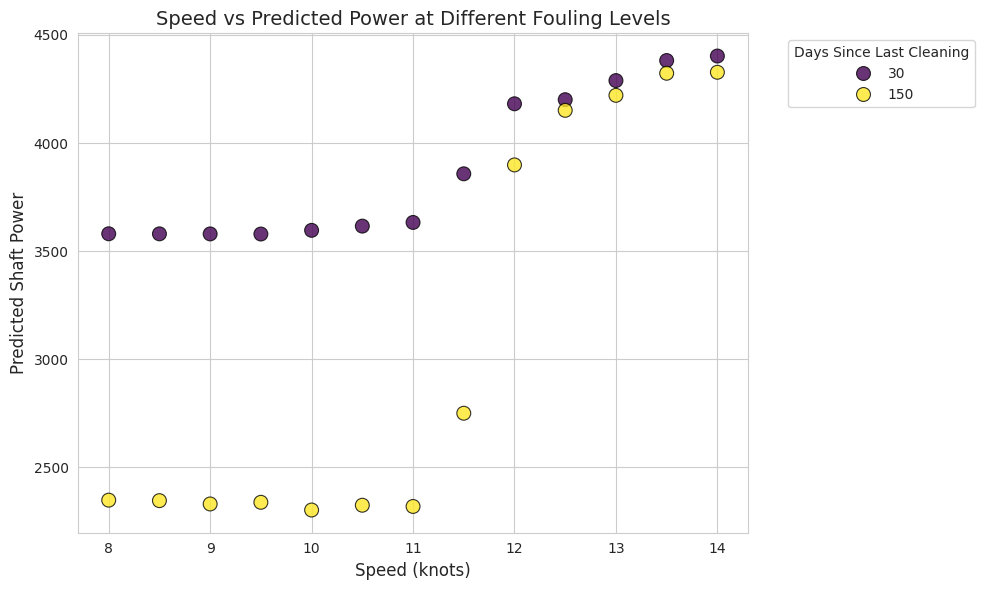

In [20]:
plot_speed_power_by_dsc(simulation_df, dsc_values=[30, 150])

In [21]:
fouling_idx = all_predictive_variables.index("Days Since Last Cleaning")
print(f"Fouling is at index: {fouling_idx}")

Fouling is at index: 3


## 3.3. GAM model

### 3.3.1. Model summary & diagnostics

Checks already confirmed:

Concurvity: Neutralized by monotonic constraints

Speed-Power Curve: Visually confirmed to follow a $V^3$ curve

Fouling Curve: Confirmed to follow a biological S-curve shape

Overfitting: Confirmed resolved (Train RMSE ≈ Test RMSE)

EDoF vs. Lambda: Confirmed model is using appropriate flexibility

Physical constraints: Confirmed monotonic on Speed, DSC, Draft, Wave Height

#### 3.3.1.1. Summary

The EDoF should not be too close to n_splines (then n_splines should be increased)

In [22]:
# 1. Extract the raw pyGAM model from our fitted pipeline
gam_pipeline = fitted_pipelines["GAM"]
actual_pygam_model = gam_pipeline.named_steps["model"].gam_model_
# 2. Generate a perfectly spaced grid of 100 points for the fouling feature
# This creates a synthetic array where ONLY the fouling feature changes.
XX = actual_pygam_model.generate_X_grid(term=fouling_idx)

# 3. Extract the partial dependence (the isolated kW penalty) and the 95% confidence intervals
pdep, confi = actual_pygam_model.partial_dependence(term=fouling_idx, X=XX, width=0.95)

# 4. We only want to plot the X-axis for the fouling variable itself
x_axis_values = XX[:, fouling_idx]

In [23]:
all_predictive_variables

['Avg Draft (Calculated)',
 'Draft Trim (Calculated)',
 'Vessel Hull Through Water Longitudinal Speed (knots)',
 'Days Since Last Cleaning',
 'Vessel External Conditions Wind Relative Angle (degrees)',
 'Vessel External Conditions Wind Relative Speed (knots)',
 'Vessel External Conditions Sea Water Temperature (Provider S)',
 'Vessel External Conditions Wave Significant Height (Provider MB)']

In [24]:
actual_pygam_model.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     35.1012
Link Function:                     IdentityLink Log Likelihood:                               -290174.4468
Number of Samples:                        38077 AIC:                                           580421.0959
                                                AICc:                                          580421.1663
                                                GCV:                                           244302.0502
                                                Scale:                                             493.859
                                                Pseudo R-Squared:                                   0.8907
Feature Function                  Lam

/tmp/ipykernel_17588/4038382217.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  actual_pygam_model.summary()


#### 3.3.1.2. Concurvity check

In [25]:
# Assuming your dataframe is 'df' and these are your features
target_feature = 'Days Since Last Cleaning'
other_features = all_predictive_variables.copy() # Add your other continuous variables here
other_features.remove(target_feature)  # Remove the target feature from the list of other features

# 1. Isolate the target feature (y) and the others (X)
y_concurvity = X_train[target_feature]
X_concurvity = X_train[other_features]

# 2. Fit a GAM predicting Days Since Cleaning based on the other features
# We use s(0) + s(1) to apply splines to both Speed and Draft
concurvity_model = LinearGAM(s(0) + s(1)).fit(X_concurvity, y_concurvity)

# 3. Extract the R-squared (Explained Deviance)
# 0.0 means no concurvity. 1.0 means complete overlap (bad).
concurvity_index = concurvity_model.statistics_['pseudo_r2']['explained_deviance']

print(f"Concurvity Index for {target_feature}: {concurvity_index:.4f}")
if concurvity_index > 0.7:
    print("WARNING: Severe concurvity detected. The model cannot separate the effect of fouling from the other variables.")


Concurvity Index for Days Since Last Cleaning: 0.9725


#### 3.3.1.3. residuals v predicted values

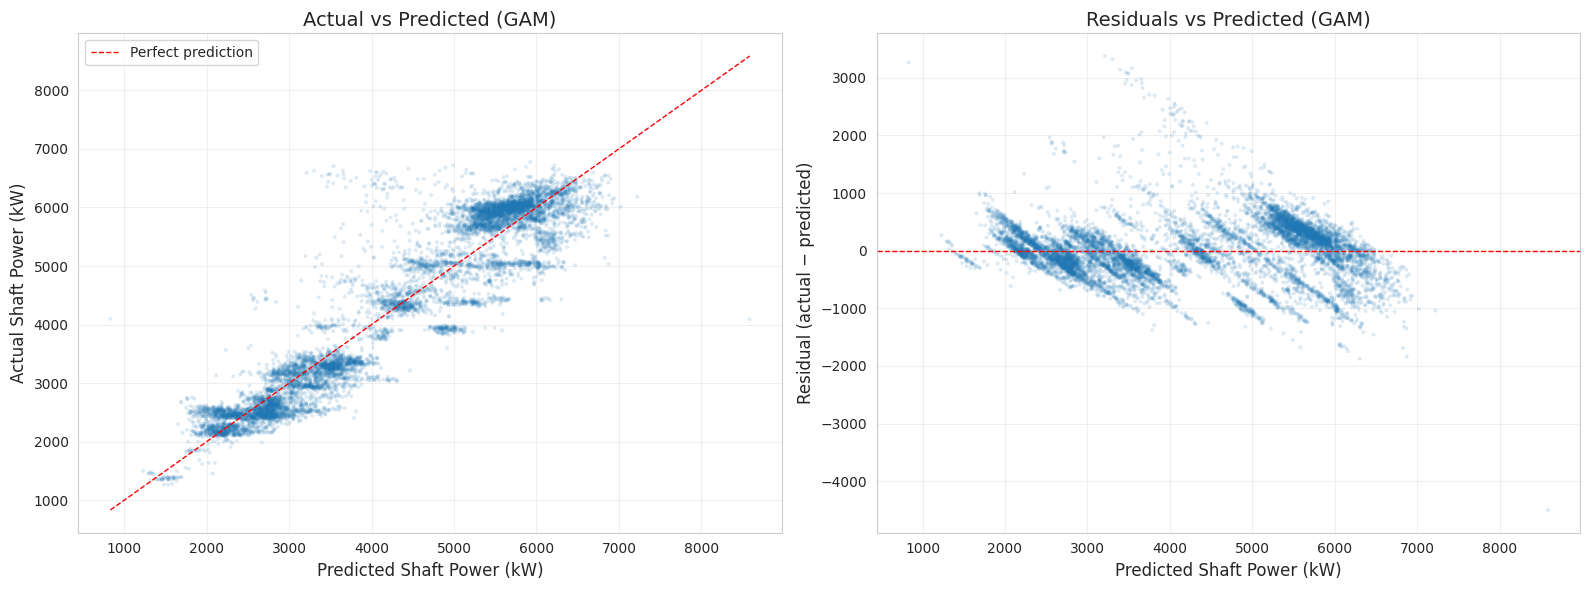

In [35]:
# Compute GAM-specific predictions on train and test sets
gam_pred_test = gam_pipeline.predict(X_test)
gam_pred_train = gam_pipeline.predict(X_train)
gam_residuals_test = np.asarray(y_test) - np.asarray(gam_pred_test)

# --- Residuals vs Predicted Values ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(gam_pred_test, y_test, alpha=0.15, s=8, edgecolors='none')
lims = [
    min(gam_pred_test.min(), y_test.min()),
    max(gam_pred_test.max(), y_test.max()),
]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel("Predicted Shaft Power (kW)", fontsize=12)
axes[0].set_ylabel("Actual Shaft Power (kW)", fontsize=12)
axes[0].set_title("Actual vs Predicted (GAM)", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals vs Predicted
axes[1].scatter(gam_pred_test, gam_residuals_test, alpha=0.15, s=8, edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Predicted Shaft Power (kW)", fontsize=12)
axes[1].set_ylabel("Residual (actual − predicted)", fontsize=12)
axes[1].set_title("Residuals vs Predicted (GAM)", fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.3.1.4. QQ plot / normality of residuals

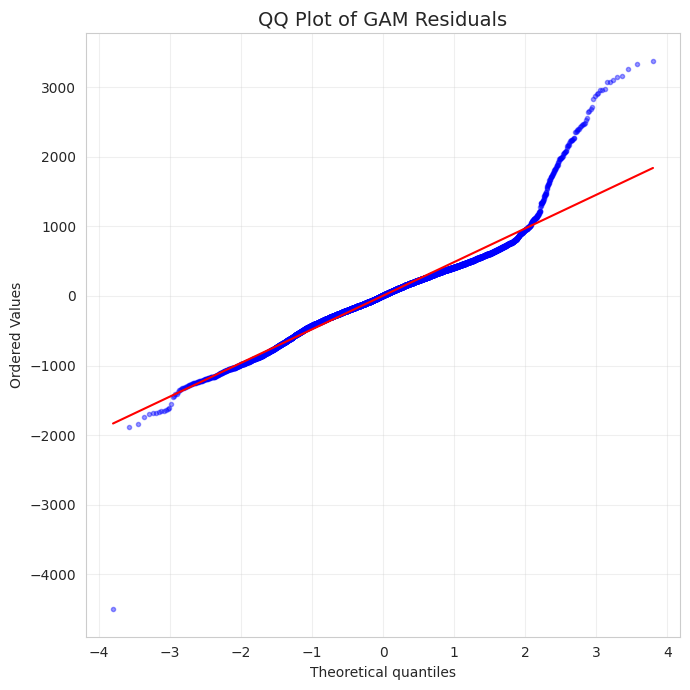

Shapiro-Wilk test  →  statistic = 0.948456,  p-value = 1.0335e-38
Residuals are NOT normally distributed (reject H₀ at α = 0.05).


In [36]:
from scipy import stats

# --- QQ Plot of GAM residuals ---
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(gam_residuals_test, dist="norm", plot=ax)
ax.set_title("QQ Plot of GAM Residuals", fontsize=14)
ax.get_lines()[0].set(markersize=3, alpha=0.4)  # data points
ax.get_lines()[1].set(color='red', linewidth=1.5)  # reference line
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Shapiro-Wilk test on a subsample (max 5000 for performance)
sample = gam_residuals_test if len(gam_residuals_test) <= 5000 else np.random.default_rng(random_seed).choice(gam_residuals_test, 5000, replace=False)
stat, p_value = stats.shapiro(sample)
print(f"Shapiro-Wilk test  →  statistic = {stat:.6f},  p-value = {p_value:.4e}")
if p_value < 0.05:
    print("Residuals are NOT normally distributed (reject H₀ at α = 0.05).")
else:
    print("Residuals appear normally distributed (fail to reject H₀ at α = 0.05).")

#### 3.3.1.5. residuals over time

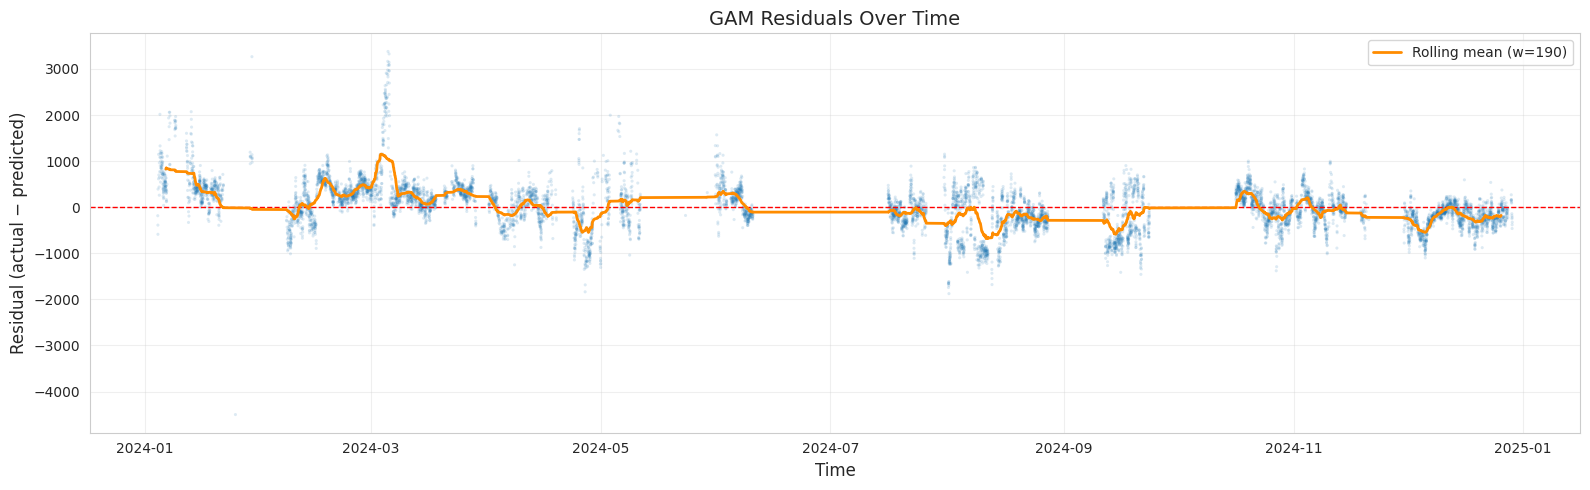

In [37]:
# --- Residuals over time ---
test_times = model_df.loc[X_test.index, "window_start"]

fig, ax = plt.subplots(figsize=(16, 5))
ax.scatter(test_times, gam_residuals_test, alpha=0.15, s=5, edgecolors='none')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Rolling mean of residuals to highlight drift
rolling_df = pd.DataFrame({"time": test_times.values, "residual": gam_residuals_test}).sort_values("time")
window = max(len(rolling_df) // 50, 10)
rolling_mean = rolling_df["residual"].rolling(window=window, center=True).mean()
ax.plot(rolling_df["time"], rolling_mean, color='darkorange', linewidth=2, label=f'Rolling mean (w={window})')

ax.set_title("GAM Residuals Over Time", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Residual (actual − predicted)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 3.3.1.6. Residuals vs days since cleaning

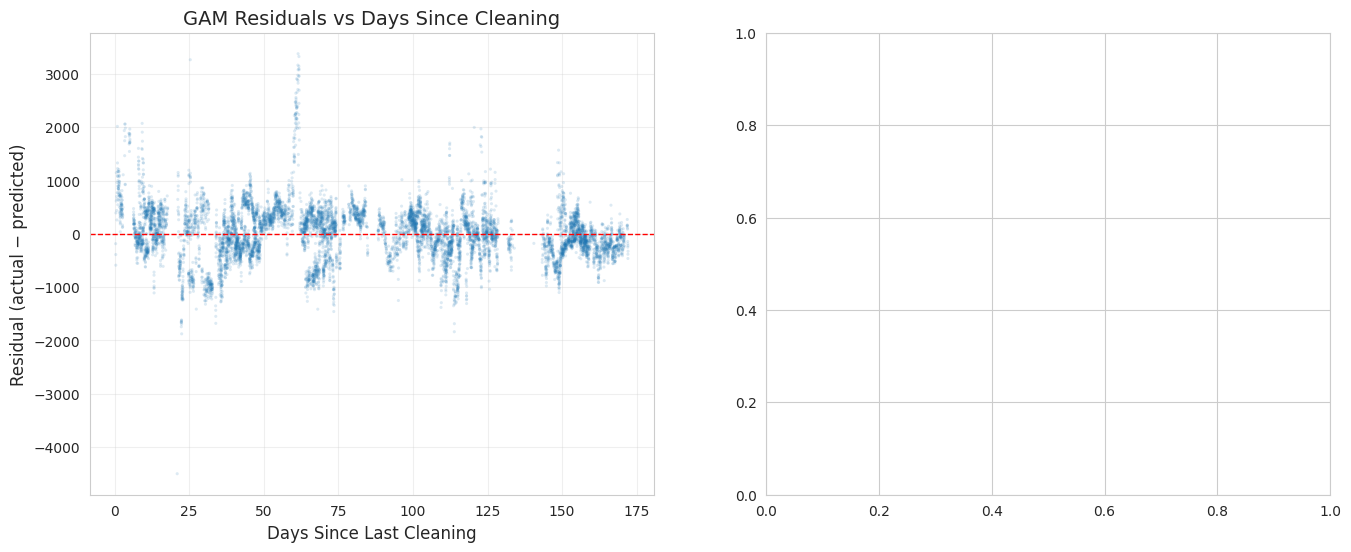

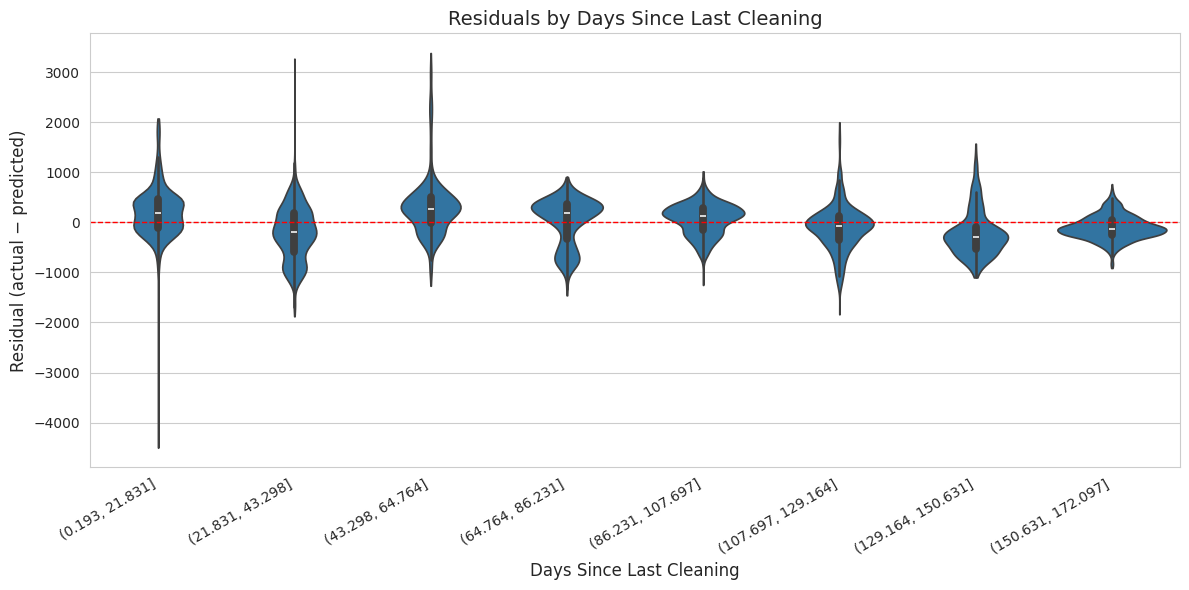

In [ ]:
def plot_residual_boxplots(
    X_test,
    y_test,
    y_pred,
    variable_name,
    n_buckets=5,
    value_limits=None,
):
    """
    Creates a violin plot of residuals bucketed by a comparison variable.

    Parameters
    ----------
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series or np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.
    variable_name : str
        Column name in X_test to bucket by.
    n_buckets : int, optional
        Number of equal-frequency (quantile) buckets (default 5).
    value_limits : tuple of (min, max), optional
        If provided, clips the comparison variable to [min, max] before
        bucketing, and drops rows outside this range.
    """
    residuals = np.asarray(y_test) - np.asarray(y_pred)
    plot_df = pd.DataFrame({
        "variable": X_test[variable_name].values,
        "residual": residuals,
    })

    # optional filtering by value limits
    if value_limits is not None:
        lo, hi = value_limits
        plot_df = plot_df[(plot_df["variable"] >= lo) & (plot_df["variable"] <= hi)]

    # create buckets using quantile-based binning
    plot_df["bucket"] = pd.cut(
        plot_df["variable"],
        bins=n_buckets,
        duplicates="drop",
    )

    # sort by bucket for a clean axis order
    plot_df = plot_df.sort_values("bucket")

    # plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        data=plot_df,
        x="bucket",
        y="residual",
        ax=ax,
        inner="box",
        cut=0,
    )
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Residuals by {variable_name}", fontsize=14)
    ax.set_xlabel(variable_name, fontsize=12)
    ax.set_ylabel("Residual (actual − predicted)", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# --- Residuals vs Days Since Last Cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter
axes[0].scatter(X_test["Days Since Last Cleaning"], gam_residuals_test, alpha=0.15, s=5, edgecolors='none')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Days Since Last Cleaning", fontsize=12)
axes[0].set_ylabel("Residual (actual − predicted)", fontsize=12)
axes[0].set_title("GAM Residuals vs Days Since Cleaning", fontsize=14)
axes[0].grid(True, alpha=0.3)

# Right: violin plot bucketed by DSC
plot_residual_boxplots(
    X_test=X_test,
    y_test=y_test,
    y_pred=gam_pred_test,
    variable_name="Days Since Last Cleaning",
    n_buckets=8,
)

#### 3.3.1.7. Sea trial curves validation

You have Particulars.xlsx which contains the ship's official sea trial speed-power curves. This is the single most credible validity check you can do for the Real Vessel Data Challenge. However, the graph is only an image and cannot be loaded, so we will have to construct the graph separately and compare visually

Filter your training data to only the first 7 days after each cleaning event (the "cleanest" the hull will ever be), predict shaft power over the speed range, and compare your GAM's speed-power curve with the sea trial curve.

If they match closely: your model is physically calibrated. If they diverge: your model has a systematic bias that needs explaining.

#### 3.3.1.8. Cleaning event reset check

4. Cleaning Event Reset Check (Not done yet — Key for fouling validity)
This is the maritime-specific validity check. Plot your raw residuals against the real calendar timeline, and mark the cleaning events as vertical lines. You should see the residuals jump toward zero (or turn negative) immediately after each cleaning event, and slowly drift positive again as days pass.

If the residuals do not reset at cleaning events, the model's fouling estimate is not being driven by the physical cleaning events, but by some other confounding variable.

### 3.3.2. Fouling / speed curve

#### 3.3.2.1. Fouling penalty by day since clean

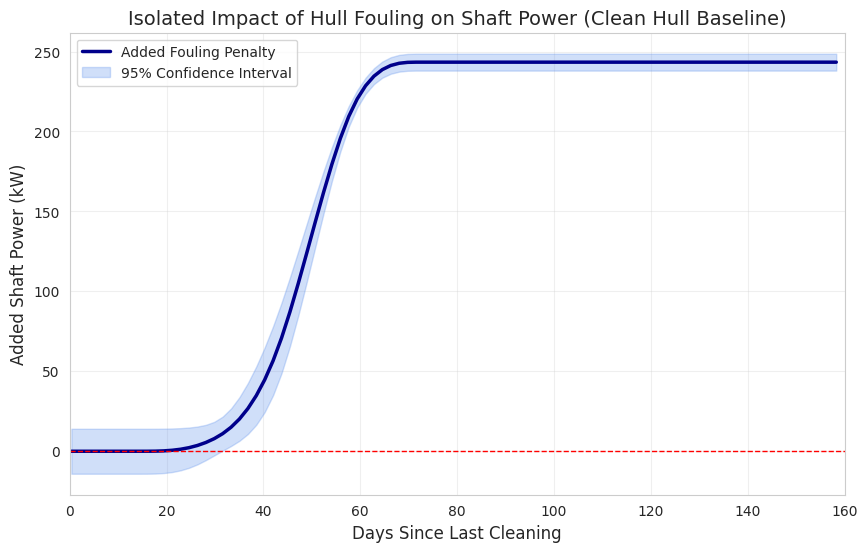

In [26]:
scaler = gam_pipeline.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"]

# 2. Unscale the grid points so the X-axis is back in real "Days"
XX_unscaled = scaler.inverse_transform(XX)
real_days = XX_unscaled[:, fouling_idx]

# 3. Filter to only include days up to 160
mask = real_days <= 160
real_days_filtered = real_days[mask]
pdep_filtered = pdep[mask]
confi_filtered = confi[mask]


# Shift the curve to start at 0 for readability
# pyGAM's generate_X_grid creates a sorted array, so the 0th index is the minimum day
baseline_power = pdep_filtered[0]

# Subtract the baseline value from both the main prediction and the CI bounds
pdep_shifted = pdep_filtered - baseline_power
confi_shifted = confi_filtered - baseline_power

# 4. Plot the final, isolated Fouling Curve
plt.figure(figsize=(10, 6))

# Plot the main partial dependence line (using SHIFTED values)
plt.plot(real_days_filtered, pdep_shifted, color='darkblue', linewidth=2.5, label='Added Fouling Penalty')

# Plot the 95% Confidence Interval bounds (using SHIFTED values)
plt.fill_between(real_days_filtered, confi_shifted[:, 0], confi_shifted[:, 1], color='cornflowerblue', alpha=0.3, label='95% Confidence Interval')

# Formatting
plt.title("Isolated Impact of Hull Fouling on Shaft Power (Clean Hull Baseline)", fontsize=14)
plt.xlabel("Days Since Last Cleaning", fontsize=12)
plt.ylabel("Added Shaft Power (kW)", fontsize=12) # Updated label to be more intuitive
plt.axhline(y=0, color='red', linestyle='--', linewidth=1) # Baseline
plt.xlim(0, 160)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [27]:
# find average shaft power in the test set
average_test_power = y_test.mean()

# find the maximum value in the plot above
max_fouling_penalty = pdep_shifted.max()
max_fouling_penalty_percentage = (max_fouling_penalty / average_test_power) * 100

print(f'max fouling penalty (kW): {max_fouling_penalty:.2f} kW')
print(f'max fouling penalty percentage: {max_fouling_penalty_percentage:.2f} %')

max fouling penalty (kW): 243.34 kW
max fouling penalty percentage: 5.69 %


### 3.3.2.1 Fouling penalty by speed

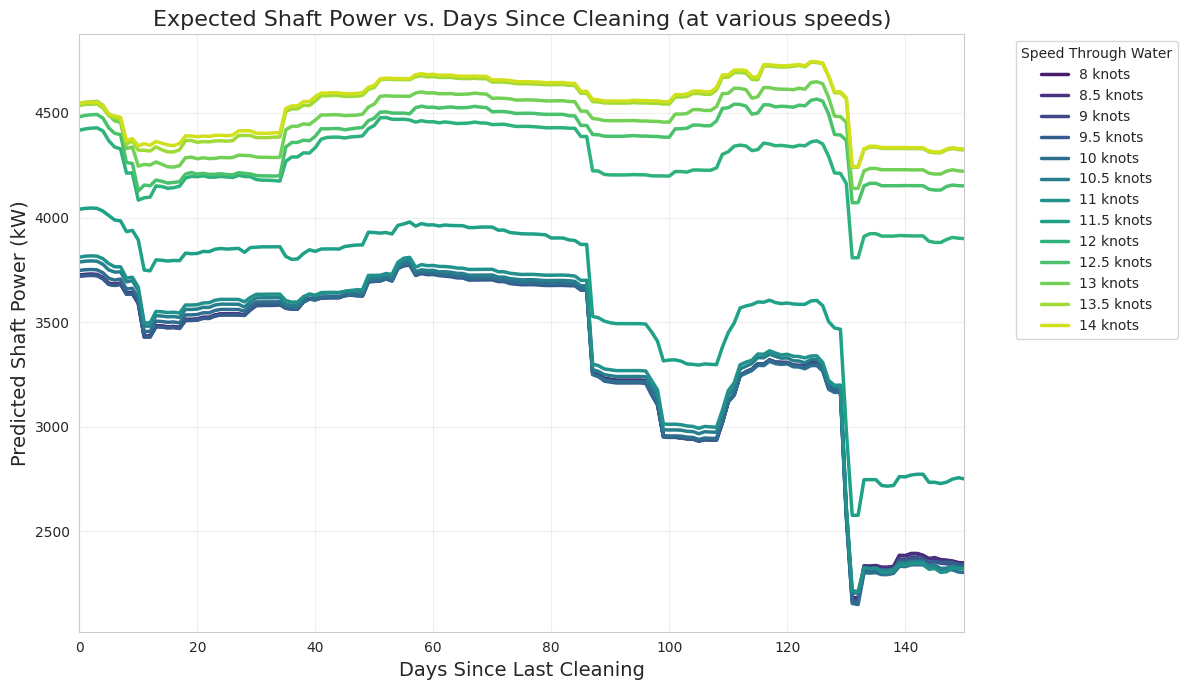

In [34]:

# Set a nice color palette for the different speeds
unique_speeds = sorted(simulation_df['Vessel Hull Through Water Longitudinal Speed (knots)'].unique())
colors = sns.color_palette("viridis", len(unique_speeds))

plt.figure(figsize=(12, 7))

# Plot one line for each Speed
for i, speed in enumerate(unique_speeds):
    # Filter the dataframe for this specific speed
    subset = simulation_df[simulation_df['Vessel Hull Through Water Longitudinal Speed (knots)'] == speed]
    
    # Plot Days vs Predicted Power
    plt.plot(
        subset['Days Since Last Cleaning'], 
        subset['Predicted Shaft Power'], 
        linewidth=2.5, 
        color=colors[i],
        label=f"{speed} knots"
    )

# Formatting
plt.title("Expected Shaft Power vs. Days Since Cleaning (at various speeds)", fontsize=16)
plt.xlabel("Days Since Last Cleaning", fontsize=14)
plt.ylabel("Predicted Shaft Power (kW)", fontsize=14)
plt.xlim(0, 150)

# Add a legend to show which line is which speed
plt.legend(title="Speed Through Water", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout() # Ensures the legend isn't cut off
plt.show()


#### 3.3.3. Speed through water

#### 3.3.3.1. Speed/power curve

Speed is at index: 2


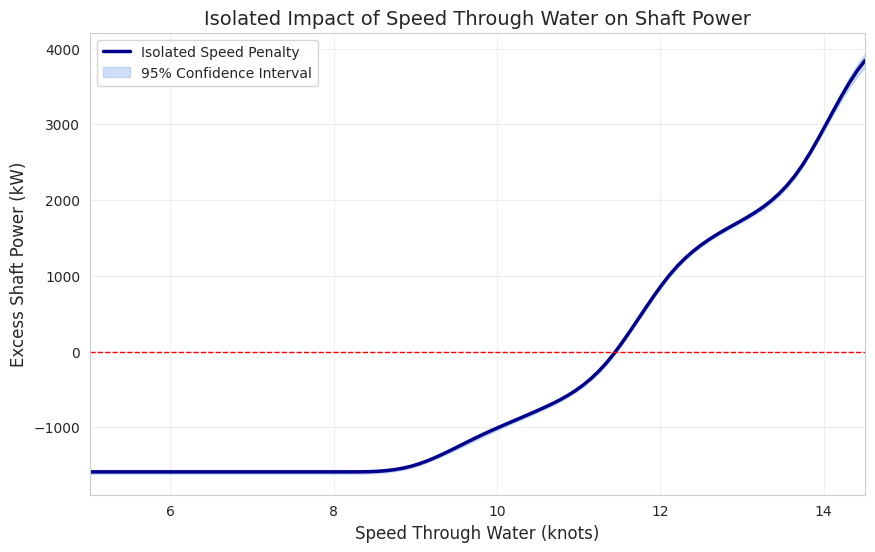

In [29]:
speed_idx = all_predictive_variables.index("Vessel Hull Through Water Longitudinal Speed (knots)")
print(f"Speed is at index: {speed_idx}")

# 2. Generate a perfectly spaced grid of 100 points for the speed feature
# This creates a synthetic array where ONLY the speed feature changes.
XX = actual_pygam_model.generate_X_grid(term=speed_idx)

# 3. Extract the partial dependence (the isolated kW penalty) and the 95% confidence intervals
pdep, confi = actual_pygam_model.partial_dependence(term=speed_idx, X=XX, width=0.95)

# 4. We only want to plot the X-axis for the speed variable itself
x_axis_values = XX[:, speed_idx]

# 2. Unscale the grid points so the X-axis is back in real "Days"
XX_unscaled = scaler.inverse_transform(XX)
real_speed = XX_unscaled[:, speed_idx]

# 3. Filter to only include days up to 160
mask = real_speed <= 160
real_speed_filtered = real_speed[mask]
pdep_filtered = pdep[mask]
confi_filtered = confi[mask]

# 4. Plot the final, isolated Speed Curve
plt.figure(figsize=(10, 6))

plt.plot(real_speed, pdep, color='darkblue', linewidth=2.5, label='Isolated Speed Penalty')
plt.fill_between(real_speed, confi[:, 0], confi[:, 1], color='cornflowerblue', alpha=0.3, label='95% Confidence Interval')

plt.title("Isolated Impact of Speed Through Water on Shaft Power", fontsize=14)
plt.xlabel("Speed Through Water (knots)", fontsize=12) 
plt.ylabel("Excess Shaft Power (kW)", fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.xlim(real_speed.min(), real_speed.max()) 

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 3.3.4. Diagnostics

##### 3.3.4.1. Speed / dsc correlation

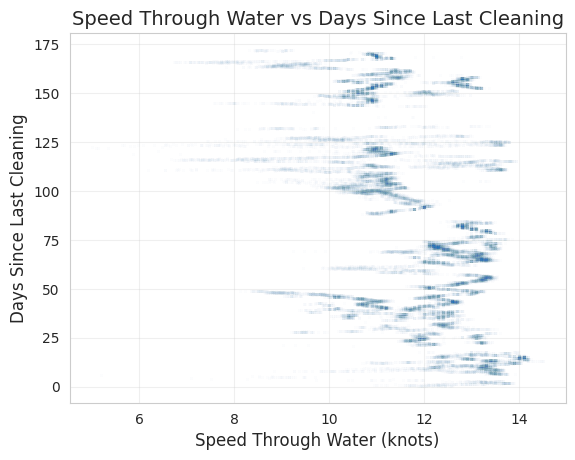

In [30]:
# TODO: Scatter speed through water vs days since cleaning
sns.scatterplot(x=X_train[speed_variable], y=X_train[dsc_variable], alpha = 0.01, s = 5, edgecolor=None)
plt.title("Speed Through Water vs Days Since Last Cleaning", fontsize=14)
plt.xlabel("Speed Through Water (knots)", fontsize=12)
plt.ylabel("Days Since Last Cleaning", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


#### 3.3.4.1. Residuals v speed

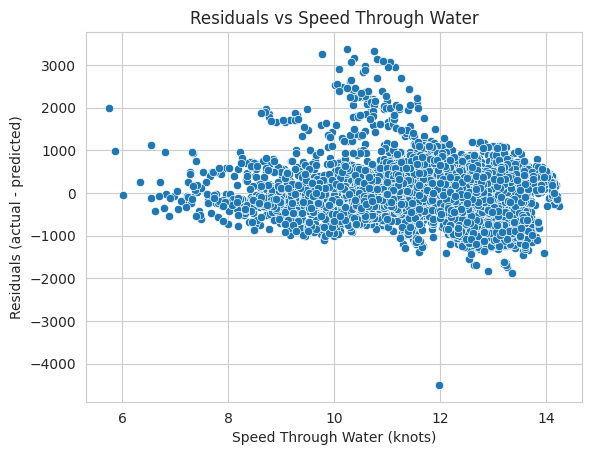

In [31]:
sns.scatterplot(x=X_test["Vessel Hull Through Water Longitudinal Speed (knots)"], y=y_test - y_pred_test)
plt.title("Residuals vs Speed Through Water")
plt.xlabel("Speed Through Water (knots)")
plt.ylabel("Residuals (actual - predicted)")
plt.show()


#### 3.3.4.2. residual vs days since clean

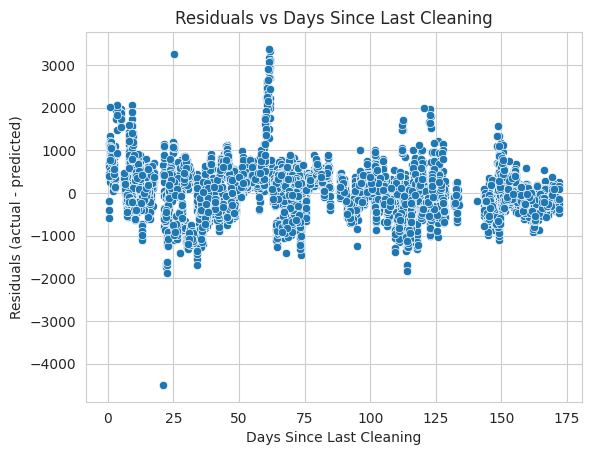

In [33]:
# scatterplot between residuals and days since clean
sns.scatterplot(x=X_test["Days Since Last Cleaning"], y=y_test - y_pred_test)
plt.title("Residuals vs Days Since Last Cleaning")
plt.xlabel("Days Since Last Cleaning")
plt.ylabel("Residuals (actual - predicted)")
plt.show()
